# T027 · 激酶相似性：配体谱

**注：** 本教程是 TeachOpenCADD 的一部分。TeachOpenCADD 是一个旨在教授领域专用技能，并提供可作为研究项目起点的流程模板的平台。

作者：

- Talia B. Kimber, 2021, [Volkamer 实验室, Charité](https://volkamerlab.org/)
- Dominique Sydow, 2021, [Volkamer 实验室, Charité](https://volkamerlab.org/)
- Andrea Volkamer, 2021, [Volkamer 实验室, Charité](https://volkamerlab.org/)


## 本教程的目标

本教程的目标是通过配体分析数据（ChEMBL29）研究激酶相似性。在药物设计领域，通常有以下假设：如果两种激酶与相似的化合物结合，那么新设计的化合物也可能会与这两种激酶结合。因此，如果两种激酶共享相似的配体谱，那么它们在配体结合方面可被认为是相似的。


### _理论_ 部分内容

* 激酶数据集
* 生物活性数据
* 激酶相似性描述符：配体谱
    * 激酶相似性
    * 激酶混杂性
* 从相似性矩阵到距离矩阵


### _实践_ 部分内容

* 定义目标激酶
* 检索数据
* 预处理数据
    * Hit 或非 hit
* 激酶混杂性
* 激酶相似性
    * 将相似性可视化为激酶矩阵
    * 保存激酶相似性矩阵
* 激酶距离矩阵
  * 保存激酶距离矩阵


### 参考文献

* 激酶数据集：[<i>Molecules</i> (2021), <b>26(3)</b>, 629](https://www.mdpi.com/1420-3049/26/3/629)
* ChEMBL 数据库
  * 网站：https://www.ebi.ac.uk/chembl/
  * 论文：[<i>Nucleic Acid Res.</i> (2019), <b>47(D1)</b>, D930-D940](https://doi.org/10.1093/nar/gky1075)
* kinodata（OpenKinome 项目）
  * GitHub：https://github.com/openkinome/kinodata
  * ChEMBL29 发布版本：https://github.com/openkinome/kinodata/releases/tag/v0.3


In [1]:
import sys

if "google.colab" in sys.modules:
    %pip install teachopencadd --no-deps -q
    !teachopencadd -d 27
    %pip uninstall teachopencadd -y -q
    %pip install -qr requirements.txt

## 理论


### 激酶数据集


我们使用 **教程 T023** 中定义的激酶选择。


### 生物活性数据


为了通过配体分析数据测量激酶相似性，我们从著名的 [ChEMBL](https://www.ebi.ac.uk/chembl/) 数据库中检索生物活性数据，查询重点关注人类激酶。


在药物设计中，通常将化合物对目标靶标的活性二值化为"hit"或"non-hit"。实际上，这是通过使用测量活性的截断值来完成的。


### 激酶相似性描述符：配体谱


作为相似性的度量，我们在本教程中使用配体分析数据。


#### 激酶相似性

我们使用以下度量作为两个激酶 $K_i$ 和 $K_j$ 之间的相似性：

$$
\text{similarity}(K_i, K_j) = \frac{\#\text{ 对两者均为活性的化合物}}{\#\text{ 对两者均进行过测试的化合物}}
$$

这是 Jaccard/Tanimoto 系数的特殊情况（参见 **教程 T004**）。


#### 激酶混杂性
计算激酶与自身的相似性可解释为激酶混杂性，其中上述相似性表示该激酶中活性化合物占测试化合物的比例。

如果激酶是高度混杂的，即它能够结合许多不同的配体，则与该激酶的自身相似性很高。如果激酶是选择性的，即只与少数配体结合，则自身相似性很低。


### 从相似性矩阵到距离矩阵

如 **教程 T024** 所述，我们将相似性矩阵转换为距离矩阵。


## 实践


In [2]:
from pathlib import Path
from collections import Counter

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole

In [3]:
HERE = Path(_dh[-1])
DATA = HERE / "data"

In [4]:
configs = pd.read_csv(DATA / "pipeline_configs.csv")
configs = configs.set_index("variable")["default_value"]
DEMO = bool(int(configs["DEMO"]))
print(f"Run in demo mode: {DEMO}")
# NBVAL_CHECK_OUTPUT

Run in demo mode: True


### 定义目标激酶


加载 **教程 T023** 中定义的激酶选择。


In [5]:
kinase_selection_df = pd.read_csv(DATA / "kinase_selection.csv")
kinase_selection_df
# NBVAL_CHECK_OUTPUT

,kinase,kinase_klifs,uniprot_id,group,full_kinase_name
0,EGFR,EGFR,P00533,TK,Epidermal growth factor receptor
1,ErbB2,ErbB2,P04626,TK,Erythroblastic leukemia viral oncogene homolog 2
2,PI3K,p110a,P42336,Atypical,Phosphatidylinositol-3-kinase
3,VEGFR2,KDR,P35968,TK,Vascular endothelial growth factor receptor 2
4,BRAF,BRAF,P15056,TKL,Rapidly accelerated fibrosarcoma isoform B
5,CDK2,CDK2,P24941,CMGC,Cyclic-dependent kinase 2
6,LCK,LCK,P06239,TK,Lymphocyte-specific protein tyrosine kinase
7,MET,MET,P08581,TK,Mesenchymal-epithelial transition factor
8,p38a,p38a,Q16539,CMGC,p38 mitogen activated protein kinase alpha


### 检索数据


我们检索 Openkinome 免费提供的 ChEMBL29 激酶子集的预整理版本，参见 https://github.com/openkinome/kinodata/releases/tag/v0.3。


In [6]:
path = "https://github.com/openkinome/kinodata/releases/download/\
v0.3/activities-chembl29_v0.3.zip"
# Load data and reset index so that it starts from 0
data = pd.read_csv(path, index_col=0).reset_index(drop=True)
print(f"Current shape of data: {data.shape}")
data.head()
# NBVAL_CHECK_OUTPUT

Current shape of data: (190634, 16)


,activities.activity_id,assays.chembl_id,target_dictionary.chembl_id,molecule_dictionary.chembl_id,molecule_dictionary.max_phase,activities.standard_type,activities.standard_value,activities.standard_units,compound_structures.canonical_smiles,compound_structures.standard_inchi,component_sequences.sequence,assays.confidence_score,docs.chembl_id,docs.year,docs.authors,UniprotID
0,16291323,CHEMBL3705523,CHEMBL2973,CHEMBL3666724,0,pIC50,14.096910,nM,CCCC(=O)Nc1cccc(-c2nc(Nc3ccc4[nH]ncc4c3)c3cc(O...,InChI=1S/C31H33N7O3/c1-2-4-29(40)33-22-6-3-5-2...,MSRPPPTGKMPGAPETAPGDGAGASRQRKLEALIRDPRSPINVESL...,9,CHEMBL3639077,2014.0,NaN,O75116
1,16264754,CHEMBL3705523,CHEMBL2973,CHEMBL3666728,0,pIC50,14.000000,nM,CCCC(=O)Nc1cccc(-c2nc(Nc3ccc4[nH]ncc4c3)c3cc(O...,InChI=1S/C34H40N8O3/c1-5-7-32(43)36-24-9-6-8-2...,MSRPPPTGKMPGAPETAPGDGAGASRQRKLEALIRDPRSPINVESL...,9,CHEMBL3639077,2014.0,NaN,O75116
2,16306943,CHEMBL3705523,CHEMBL2973,CHEMBL1968705,0,pIC50,14.000000,nM,CCCC(=O)Nc1cccc(-c2nc(Nc3ccc4[nH]ncc4c3)c3cc(O...,InChI=1S/C31H33N7O2/c1-2-6-29(39)33-23-8-5-7-2...,MSRPPPTGKMPGAPETAPGDGAGASRQRKLEALIRDPRSPINVESL...,9,CHEMBL3639077,2014.0,NaN,O75116
3,16340050,CHEMBL3705523,CHEMBL2973,CHEMBL1997433,0,pIC50,13.958607,nM,CCCC(=O)Nc1cccc(-c2nc(Nc3ccc4[nH]ncc4c3)c3cc(O...,InChI=1S/C28H28N6O3/c1-3-5-26(35)30-20-7-4-6-1...,MSRPPPTGKMPGAPETAPGDGAGASRQRKLEALIRDPRSPINVESL...,9,CHEMBL3639077,2014.0,NaN,O75116
4,16287186,CHEMBL3705523,CHEMBL2973,CHEMBL3666721,0,pIC50,13.920819,nM,CCCC(=O)Nc1cccc(-c2nc(Nc3ccc4[nH]ncc4c3)c3cc(O...,InChI=1S/C32H35N7O2/c1-2-7-30(40)34-24-9-6-8-2...,MSRPPPTGKMPGAPETAPGDGAGASRQRKLEALIRDPRSPINVESL...,9,CHEMBL3639077,2014.0,NaN,O75116


### 预处理数据


我们查看活性类型和关联的单位。


In [7]:
print(
    f"Activities: {sorted(set(data['activities.standard_type']))}\n"
    f"Units: {set(data['activities.standard_units'])}"
)

Activities: ['pIC50', 'pKd', 'pKi']
Units: {'nM'}


我们仅保留具有 pIC50 值的条目。


In [8]:
data = data[data["activities.standard_type"] == "pIC50"]

In [9]:
data.columns
# NBVAL_CHECK_OUTPUT

Index(['activities.activity_id', 'assays.chembl_id',
       'target_dictionary.chembl_id', 'molecule_dictionary.chembl_id',
       'molecule_dictionary.max_phase', 'activities.standard_type',
       'activities.standard_value', 'activities.standard_units',
       'compound_structures.canonical_smiles',
       'compound_structures.standard_inchi', 'component_sequences.sequence',
       'assays.confidence_score', 'docs.chembl_id', 'docs.year',
       'docs.authors', 'UniprotID'],
      dtype='str')

DataFrame 包含许多对本 notebook 后续部分不必要的列，因此将其删除。只保留相关信息，即化合物的规范 SMILES（`canonical_smiles`）、靶标基因名（`target_genesymbol`）、标准类型（`standard_type`）和标准值（`standard_value`）。


In [10]:
data = data[["compound_structures.canonical_smiles", "activities.standard_value", "UniprotID"]]
data = data.rename(
    columns={
        "compound_structures.canonical_smiles": "smiles",
        "activities.standard_value": "pIC50",
    }
)

In [11]:
print(f"Current shape of data: {data.shape}")
data.head()
# NBVAL_CHECK_OUTPUT

Current shape of data: (160857, 3)


,smiles,pIC50,UniprotID
0,CCCC(=O)Nc1cccc(-c2nc(Nc3ccc4[nH]ncc4c3)c3cc(O...,14.096910,O75116
1,CCCC(=O)Nc1cccc(-c2nc(Nc3ccc4[nH]ncc4c3)c3cc(O...,14.000000,O75116
2,CCCC(=O)Nc1cccc(-c2nc(Nc3ccc4[nH]ncc4c3)c3cc(O...,14.000000,O75116
3,CCCC(=O)Nc1cccc(-c2nc(Nc3ccc4[nH]ncc4c3)c3cc(O...,13.958607,O75116
4,CCCC(=O)Nc1cccc(-c2nc(Nc3ccc4[nH]ncc4c3)c3cc(O...,13.920819,O75116


丢弃 NA 值。


In [12]:
data = data.dropna()
print(f"Current shape of data: {data.shape}")
# NBVAL_CHECK_OUTPUT

Current shape of data: (160703, 3)


我们只保留查询激酶的数据：


In [13]:
data = data[data["UniprotID"].isin(kinase_selection_df["uniprot_id"])]
print(f"Current shape of data: {data.shape}")
data.head()
# NBVAL_CHECK_OUTPUT

Current shape of data: (33427, 3)


,smiles,pIC50,UniprotID
58,Brc1cccc(Nc2ncnc3cc4ccccc4cc23)c1,11.522879,P00533
98,CN(C)c1cc2c(Nc3cccc(Br)c3)ncnc2cn1,11.221849,P00533
99,CCOc1cc2ncnc(Nc3cccc(Br)c3)c2cc1OCC,11.221849,P00533
140,CNc1cc2c(Nc3cccc(Br)c3)ncnc2cn1,11.096910,P00533
141,Brc1cccc(Nc2ncnc3cc4[nH]cnc4cc23)c1,11.096910,P00533


让我们查看示例数据（对应于激酶选择 DataFrame 中的第一行）：


In [14]:
example_kinase = kinase_selection_df["kinase_klifs"][0]
example_uniprot = kinase_selection_df["uniprot_id"][0]

example_data = data[data["UniprotID"] == example_uniprot]

print(f"Example kinase: {example_kinase}")

Example kinase: EGFR


某些化合物已对同一靶标进行了多次测试，如下所示。


In [15]:
measured_compounds = Counter(example_data["smiles"])
try:
    top_measured_compounds = measured_compounds.most_common()[0:5]
except IndexError:
    top_measured_compounds = measured_compounds.most_common()
top_measured_compounds
# NBVAL_CHECK_OUTPUT

[('COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCCCN1CCOCC1', 39),
 ('C#Cc1cccc(Nc2ncnc3cc(OCCOC)c(OCCOC)cc23)c1', 27),
 ('C=CC(=O)Nc1cc(Nc2nccc(-c3cn(C)c4ccccc34)n2)c(OC)cc1N(C)CCN(C)C', 15),
 ('C=CC(=O)Nc1cccc(Oc2nc(Nc3ccc(N4CCN(C)CC4)cc3OC)ncc2Cl)c1', 11),
 ('CS(=O)(=O)CCNCc1ccc(-c2ccc3ncnc(Nc4ccc(OCc5cccc(F)c5)c(Cl)c4)c3c2)o1', 8)]

我们来看一下这些化合物。


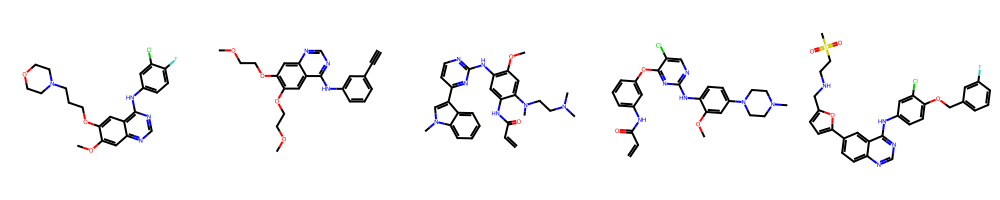

In [16]:
mols = []
for entry in top_measured_compounds:
    mols.append(Chem.MolFromSmiles(entry[0]))
Draw.MolsToGridImage(mols, molsPerRow=5)

在此示例（演示模式）中，第一个分子是吉非替尼（gefitinib），一种已知的 FDA 批准的 EGFR 靶向药物。


作为简单的解决方案——因为我们更倾向于每个化合物-激酶对有一个活性值——我们保留该化合物活性值最好的值，即最高的 pIC50 值。


In [17]:
data = data.groupby(["UniprotID", "smiles"])["pIC50"].max().reset_index()
data.head()
# NBVAL_CHECK_OUTPUT

,UniprotID,smiles,pIC50
0,P00533,Br.CC(Nc1ncnc2[nH]c(-c3ccc(O)cc3)cc12)c1ccc(C(...,5.336488
1,P00533,Br.CC(Nc1ncnc2[nH]c(-c3ccc(O)cc3)cc12)c1cccc2c...,5.996539
2,P00533,Br.CC[C@@H](Nc1ncnc2[nH]c(-c3ccc(O)cc3)cc12)c1...,8.397940
3,P00533,Br.C[C@@H](Nc1ncnc2[nH]c(-c3ccc(O)cc3)cc12)c1c...,7.207608
4,P00533,Br.C[C@@H](Nc1ncnc2[nH]c(-c3ccc(O)cc3)cc12)c1c...,8.420216


#### Hit 或非 hit

最后，我们使用截断值将 pIC50 值二值化为 hit 或 non-hit。我们使用 pIC50 截断值 6.3，与 [<i>Molecules</i> (2021), <b>26(3)</b>, 629](https://www.mdpi.com/1420-3049/26/3/629) 中使用的截断值类似。


Finally, we binarize the pIC50 values to obtain hit or non-hit using a cutoff. We use a pIC50 cutoff of $6.3$, similarly to the cutoff used in [<i>Molecules</i> (2021), <b>26(3)</b>, 629](https://www.mdpi.com/1420-3049/26/3/629).

In [18]:
cutoff = 6.3

In [19]:
def binarize_pic50(pic50_value, threshold):
    """
    Binarizes a scalar value given a threshold.

    Parameters
    ----------
    pic50_value : float
        The measurement pIC50 value of a kinase-ligand pair.
    threshold : float
        The cutoff to determine activity.

    Returns
    -------
    int
        1 if the pIC50 value is above the threshold, which indicates activity.
        0 otherwise.
    """
    if pic50_value >= threshold:
        return 1
    else:
        return 0

In [20]:
data["activity_binary"] = data["pIC50"].apply(binarize_pic50, args=(cutoff,))

In [21]:
print(f"Current shape of data: {data.shape}")
data.head()
# NBVAL_CHECK_OUTPUT

Current shape of data: (32916, 4)


,UniprotID,smiles,pIC50,activity_binary
0,P00533,Br.CC(Nc1ncnc2[nH]c(-c3ccc(O)cc3)cc12)c1ccc(C(...,5.336488,0
1,P00533,Br.CC(Nc1ncnc2[nH]c(-c3ccc(O)cc3)cc12)c1cccc2c...,5.996539,0
2,P00533,Br.CC[C@@H](Nc1ncnc2[nH]c(-c3ccc(O)cc3)cc12)c1...,8.397940,1
3,P00533,Br.C[C@@H](Nc1ncnc2[nH]c(-c3ccc(O)cc3)cc12)c1c...,7.207608,1
4,P00533,Br.C[C@@H](Nc1ncnc2[nH]c(-c3ccc(O)cc3)cc12)c1c...,8.420216,1


### 激酶混杂性

现在我们来查看激酶的混杂性。

对于给定的激酶，计算三个值：

1. 对该激酶进行过测试的化合物总数，
2. 对该激酶有活性的化合物数量，
3. 前两个值的比值：激酶混杂性。


We now look at the kinase promiscuity.

For a given kinase, three values are computed:

1. the total number of measured compounds against the given kinase,
2. the number of active compounds against the kinase, and
3. the fraction of active compounds, i.e., the ratio of active compounds over the total number of measured compounds per kinase.

In [22]:
def kinase_to_activity_numbers(uniprot_id, activity_df):
    """
    Retrieve the three values for a given kinase.

    Parameters
    ----------
    uniprot_id : str
        The UniProt ID of the kinase of interest, e.g. "P00533" for "EGFR".
    activity_df : pd.DataFrame
        The dataframe with activity values for kinases.

    Returns
    -------
    tuple : (int, int, float)
        The three metrics:
        1. The total number of measured compounds against the kinase.
        2. The number of active compounds against the kinase.
        3. The fraction of active compounds against the kinase.
    """
    kinase_data = activity_df[activity_df["UniprotID"] == uniprot_id]
    total_measured_compounds = len(kinase_data)
    active_compounds = len(kinase_data[kinase_data["activity_binary"] == 1])
    if total_measured_compounds > 0:
        fraction = active_compounds / total_measured_compounds
    else:
        print("No compounds were measured for this kinase.")
        fraction = np.nan
    return (total_measured_compounds, active_compounds, fraction)

让我们看看数据集中第一个激酶获得了哪些信息：


In [23]:
example_kinase = kinase_selection_df["kinase_klifs"][0]
example_uniprot = kinase_selection_df["uniprot_id"][0]

print(f"{example_kinase} ({example_uniprot}):")
example_metrics = kinase_to_activity_numbers(example_uniprot, data)
print(
    f"{'Total number of measured compounds:' : <40}"
    f"{example_metrics[0]} \n"
    f"{'Number of active compounds:' : <40}"
    f"{example_metrics[1]} \n"
    f"{'Fraction of active compounds:' : <40}"
    f"{example_metrics[2]:.2f} \n"
)
# NBVAL_CHECK_OUTPUT

EGFR (P00533):
Total number of measured compounds:     5965 
Number of active compounds:             3635 
Fraction of active compounds:           0.61 



让我们为所有激酶创建一个包含这些值的表格：


In [24]:
def promiscuity_table(kinase_selection, activity_df):
    """
    Create a table with all three values for all kinases.

    Parameters
    ----------
    kinase_selection : pd.DataFrame
        The DataFrame for the chosen kinases.
    activity_df : pd.DataFrame
        The DataFrame with activity values for kinases.

    Returns
    -------
    promiscuity_table : pd.DataFrame
        A DataFrame with the kinases as rows and values as columns.
    """
    promiscuity_table = pd.DataFrame(
        index=kinase_selection["kinase_klifs"], columns=["total", "actives", "fraction"]
    )
    promiscuity_table.index.name = None
    promiscuity_table.columns.name = None

    for name, uniprot_id in zip(kinase_selection["kinase_klifs"], kinase_selection["uniprot_id"]):
        values = kinase_to_activity_numbers(uniprot_id, activity_df)
        promiscuity_table.loc[name] = values
    return promiscuity_table

In [25]:
kinase_promiscuity_df = promiscuity_table(kinase_selection_df, data)
kinase_promiscuity_df
# NBVAL_CHECK_OUTPUT

,total,actives,fraction
EGFR,5965,3635,0.609388
ErbB2,1700,1031,0.606471
p110a,4393,2827,0.643524
KDR,7641,5328,0.697291
BRAF,3688,2992,0.81128
CDK2,1500,815,0.543333
LCK,1560,935,0.599359
MET,2832,2248,0.793785
p38a,3637,2778,0.763816


美化表格：


In [26]:
kinase_promiscuity_df.style.format("{:.3f}", subset=["fraction"]).background_gradient(
    cmap="Purples", subset=["fraction"]
).highlight_min(color="yellow", axis=None, subset=["fraction"]).highlight_max(
    color="red", subset=["fraction"]
)

,total,actives,fraction
EGFR,5965,3635,0.609
ErbB2,1700,1031,0.606
p110a,4393,2827,0.644
KDR,7641,5328,0.697
BRAF,3688,2992,0.811
CDK2,1500,815,0.543
LCK,1560,935,0.599
MET,2832,2248,0.794
p38a,3637,2778,0.764


从表格中可以看出，CDK2 是混杂性最低的激酶（黄色），而 BRAF 是混杂性最高的激酶（红色）。

_注意_：如果某个激酶只测试了很少的化合物，混杂性分数可能会产生偏差。


### 激酶相似性


现在我们研究如何使用_理论_部分讨论的相似性度量来比较激酶。


In [27]:
def similarity_ligand_profile(uniprot_id1, uniprot_id2, activity_df):
    """
    Compute the similarity between two kinases using ligand profiling data.

    Parameters
    ----------
    uniprot_id1 : str
        UniProt ID of first kinase of interest.
    uniprot_id2 : str
        UniProt ID of second kinase of interest.
    activity_df :  pd.DataFrame
        The DataFrame with activity values for kinases.

    Returns
    -------
    tuple : (int, int, float)
        The three metrics:
        1. The total number of measured compounds against both kinases.
        2. The number of active compounds against both kinases.
        3. The metric for kinase similarity,
                i.e. number of active compounds on both kinases
                over number of measured compounds on both kinases.
    """
    if uniprot_id1 == uniprot_id2:
        return kinase_to_activity_numbers(uniprot_id1, activity_df)
    else:
        # Data for the two kinases only
        reduced_data = activity_df[activity_df["UniprotID"].isin([uniprot_id1, uniprot_id2])]

        # Look at active compounds only
        active_entries = reduced_data[reduced_data["activity_binary"] == 1]
        # Group by compounds
        compounds = active_entries.groupby("smiles").size()
        # Look at the number of active compounds measured on both kinases
        active_compounds_on_both = compounds[compounds == 2].shape[0]

        # Look at all tested compounds
        compounds = reduced_data.groupby("smiles").size()
        # Look at the number of compounds measured on both kinases
        measured_compounds_on_both = compounds[compounds == 2].shape[0]

        if measured_compounds_on_both > 0:
            fraction = active_compounds_on_both / measured_compounds_on_both
        else:
            print(
                f"No compounds were measured on both kinases, "
                f"namely {uniprot_id1} and {uniprot_id2}."
            )
            fraction = np.nan
            measured_compounds_on_both = np.nan
            active_compounds_on_both = np.nan
        return (measured_compounds_on_both, active_compounds_on_both, fraction)

让我们查看两个激酶之间的值和相似性。


In [28]:
if DEMO:
    kinase1 = "EGFR"
    uniprot1 = "P00533"
    kinase2 = "MET"
    uniprot2 = "P08581"
else:
    kinase1 = kinase_selection_df["kinase_klifs"][0]
    uniprot1 = kinase_selection_df["uniprot_id"][0]
    kinase2 = kinase_selection_df["kinase_klifs"][1]
    uniprot2 = kinase_selection_df["uniprot_id"][1]

similarity_example = similarity_ligand_profile(uniprot1, uniprot2, data)
print(
    f"Values for {kinase1} and {kinase2}: \n\n"
    f"{'Total number of measured compounds:' : <50}"
    f"{similarity_example[0]} \n"
    f"{'Number of active compounds:' : <50}"
    f"{similarity_example[1]} \n"
    f"Fraction of active compounds or \n"
    f"{'ligand profile similarity:' : <50}"
    f"{similarity_example[2]:.2f} \n"
)
# NBVAL_CHECK_OUTPUT

Values for EGFR and MET: 

Total number of measured compounds:               92 
Number of active compounds:                       21 
Fraction of active compounds or 
ligand profile similarity:                        0.23 



#### 将相似性可视化为激酶矩阵


让我们首先查看非约简的比率（活性化合物数占活跃化合物总数的比例），以了解计数情况。


In [29]:
kinase_counts_matrix = pd.DataFrame(
    index=kinase_selection_df.kinase_klifs, columns=kinase_selection_df.kinase_klifs
)
kinase_counts_matrix.index.name = None
kinase_counts_matrix.columns.name = None

for i, (uniprot_id1, klifs_name1) in enumerate(
    zip(kinase_selection_df.uniprot_id, kinase_selection_df.kinase_klifs)
):
    for j, (uniprot_id2, klifs_name2) in enumerate(
        zip(kinase_selection_df.uniprot_id, kinase_selection_df.kinase_klifs)
    ):
        total, actives, _ = similarity_ligand_profile(uniprot_id1, uniprot_id2, data)
        integer_ratio = f"{actives}/{total}"
        kinase_counts_matrix.loc[klifs_name1, klifs_name2] = integer_ratio
kinase_counts_matrix
# NBVAL_CHECK_OUTPUT

No compounds were measured on both kinases, namely P04626 and P42336.
No compounds were measured on both kinases, namely P42336 and P04626.


,EGFR,ErbB2,p110a,KDR,BRAF,CDK2,LCK,MET,p38a
EGFR,3635/5965,662/1170,13/179,313/893,27/59,5/40,31/126,21/92,18/52
ErbB2,662/1170,1031/1700,nan/nan,72/180,4/16,4/27,5/33,1/28,2/16
p110a,13/179,nan/nan,2827/4393,32/174,1/3,4/12,0/3,0/1,0/5
KDR,313/893,72/180,32/174,5328/7641,199/262,71/115,179/413,184/340,63/122
BRAF,27/59,4/16,1/3,199/262,2992/3688,1/13,22/40,3/26,29/41
CDK2,5/40,4/27,4/12,71/115,1/13,815/1500,2/18,2/22,1/9
LCK,31/126,5/33,0/3,179/413,22/40,2/18,935/1560,17/63,69/138
MET,21/92,1/28,0/1,184/340,3/26,2/22,17/63,2248/2832,1/20
p38a,18/52,2/16,0/5,63/122,29/41,1/9,69/138,1/20,2778/3637


请注意，对两种激酶进行过测试的化合物总数以及活性化合物数量存在很大差异。

* 对于 p110a-ErbB2 对，没有共同测试的化合物。
* 对于 p110a 和 [BRAF, CDK2, LCK, MET, KDR] 对，只有很少的共同测试化合物。
* 对于密切相关的激酶（例如 EGFR 和 ErbB2、CDK2 和 CDK4、IGF1R 和 INSR），有许多共同测试的化合物。


现在让我们来看相似性，即约简后的比率：


In [30]:
kinase_similarity_matrix = np.zeros((len(kinase_selection_df), len(kinase_selection_df)))
for i, uniprot_id1 in enumerate(kinase_selection_df.uniprot_id):
    for j, uniprot_id2 in enumerate(kinase_selection_df.uniprot_id):
        kinase_similarity_matrix[i, j] = similarity_ligand_profile(uniprot_id1, uniprot_id2, data)[
            2
        ]

No compounds were measured on both kinases, namely P04626 and P42336.
No compounds were measured on both kinases, namely P42336 and P04626.


In [31]:
kinase_similarity_matrix_df = pd.DataFrame(
    data=kinase_similarity_matrix,
    index=kinase_selection_df.kinase_klifs,
    columns=kinase_selection_df.kinase_klifs,
)
kinase_similarity_matrix_df.index.name = None
kinase_similarity_matrix_df.columns.name = None
kinase_similarity_matrix_df
# NBVAL_CHECK_OUTPUT

,EGFR,ErbB2,p110a,KDR,BRAF,CDK2,LCK,MET,p38a
EGFR,0.609388,0.565812,0.072626,0.350504,0.457627,0.125000,0.246032,0.228261,0.346154
ErbB2,0.565812,0.606471,NaN,0.400000,0.250000,0.148148,0.151515,0.035714,0.125000
p110a,0.072626,NaN,0.643524,0.183908,0.333333,0.333333,0.000000,0.000000,0.000000
KDR,0.350504,0.400000,0.183908,0.697291,0.759542,0.617391,0.433414,0.541176,0.516393
BRAF,0.457627,0.250000,0.333333,0.759542,0.811280,0.076923,0.550000,0.115385,0.707317
CDK2,0.125000,0.148148,0.333333,0.617391,0.076923,0.543333,0.111111,0.090909,0.111111
LCK,0.246032,0.151515,0.000000,0.433414,0.550000,0.111111,0.599359,0.269841,0.500000
MET,0.228261,0.035714,0.000000,0.541176,0.115385,0.090909,0.269841,0.793785,0.050000
p38a,0.346154,0.125000,0.000000,0.516393,0.707317,0.111111,0.500000,0.050000,0.763816


In [32]:
# Show matrix with background gradient
cm = sns.light_palette("green", as_cmap=True)
kinase_similarity_matrix_df.style.background_gradient(cmap=cm).format("{:.3f}")

,EGFR,ErbB2,p110a,KDR,BRAF,CDK2,LCK,MET,p38a
EGFR,0.609,0.566,0.073,0.351,0.458,0.125,0.246,0.228,0.346
ErbB2,0.566,0.606,nan,0.400,0.250,0.148,0.152,0.036,0.125
p110a,0.073,nan,0.644,0.184,0.333,0.333,0.000,0.000,0.000
KDR,0.351,0.400,0.184,0.697,0.760,0.617,0.433,0.541,0.516
BRAF,0.458,0.250,0.333,0.760,0.811,0.077,0.550,0.115,0.707
CDK2,0.125,0.148,0.333,0.617,0.077,0.543,0.111,0.091,0.111
LCK,0.246,0.152,0.000,0.433,0.550,0.111,0.599,0.270,0.500
MET,0.228,0.036,0.000,0.541,0.115,0.091,0.270,0.794,0.050
p38a,0.346,0.125,0.000,0.516,0.707,0.111,0.500,0.050,0.764


注意，对角线包含之前讨论过的混杂性值。

如上所述，ErbB2 和 p110a 之间没有共同测试的化合物，因此产生了一个 `np.nan` 条目，在后续分析中可以忽略。


In [33]:
kinase_similarity_matrix_df = kinase_similarity_matrix_df.fillna(0)

kinase_similarity_matrix_df.style.background_gradient(cmap=cm).format("{:.3f}")

,EGFR,ErbB2,p110a,KDR,BRAF,CDK2,LCK,MET,p38a
EGFR,0.609,0.566,0.073,0.351,0.458,0.125,0.246,0.228,0.346
ErbB2,0.566,0.606,0.000,0.400,0.250,0.148,0.152,0.036,0.125
p110a,0.073,0.000,0.644,0.184,0.333,0.333,0.000,0.000,0.000
KDR,0.351,0.400,0.184,0.697,0.760,0.617,0.433,0.541,0.516
BRAF,0.458,0.250,0.333,0.760,0.811,0.077,0.550,0.115,0.707
CDK2,0.125,0.148,0.333,0.617,0.077,0.543,0.111,0.091,0.111
LCK,0.246,0.152,0.000,0.433,0.550,0.111,0.599,0.270,0.500
MET,0.228,0.036,0.000,0.541,0.115,0.091,0.270,0.794,0.050
p38a,0.346,0.125,0.000,0.516,0.707,0.111,0.500,0.050,0.764


#### 保存激酶相似性矩阵


In [34]:
kinase_similarity_matrix_df.to_csv(DATA / "kinase_similarity_matrix.csv")

### 激酶距离矩阵


相似性矩阵 $SM$ 被转换为伪距离矩阵（相似性矩阵的所有条目都在 0 和 1 之间）：


In [35]:
print(
    f"The values of the similarity matrix lie between: "
    f"{kinase_similarity_matrix_df.min().min():.2f}"
    f" and {kinase_similarity_matrix_df.max().max():.2f}"
)
# NBVAL_CHECK_OUTPUT

The values of the similarity matrix lie between: 0.00 and 0.81


In [36]:
kinase_distance_matrix_df = 1 - kinase_similarity_matrix_df

最后，我们将对角线值设为 0，得到激酶距离矩阵：


In [37]:
# np.fill_diagonal(kinase_distance_matrix_df.values, 0) # read-only error
# safe assignment
for i in range(len(kinase_distance_matrix_df)):
    kinase_distance_matrix_df.iloc[i, i] = 0

In [38]:
kinase_distance_matrix_df.style.background_gradient(cmap=cm).format("{:.3f}")

,EGFR,ErbB2,p110a,KDR,BRAF,CDK2,LCK,MET,p38a
EGFR,0.000,0.434,0.927,0.649,0.542,0.875,0.754,0.772,0.654
ErbB2,0.434,0.000,1.000,0.600,0.750,0.852,0.848,0.964,0.875
p110a,0.927,1.000,0.000,0.816,0.667,0.667,1.000,1.000,1.000
KDR,0.649,0.600,0.816,0.000,0.240,0.383,0.567,0.459,0.484
BRAF,0.542,0.750,0.667,0.240,0.000,0.923,0.450,0.885,0.293
CDK2,0.875,0.852,0.667,0.383,0.923,0.000,0.889,0.909,0.889
LCK,0.754,0.848,1.000,0.567,0.450,0.889,0.000,0.730,0.500
MET,0.772,0.964,1.000,0.459,0.885,0.909,0.730,0.000,0.950
p38a,0.654,0.875,1.000,0.484,0.293,0.889,0.500,0.950,0.000


#### 保存激酶距离矩阵


In [39]:
kinase_distance_matrix_df.to_csv(DATA / "kinase_distance_matrix.csv")

## 讨论

在本教程中，我们研究了如何将活性数据用作激酶之间相似性的度量。在对两种激酶进行过测试的化合物中活性化合物的比例被用作相似性得分。该相似性矩阵将在 **教程 T028** 中进一步讨论。

一个重要的警告：由于缺少共同测试的化合物，某些激酶对无法进行比较。这可能发生在属于不同激酶家族的激酶上。在这种情况下，可以考虑使用其他激酶相似性度量。


## 测验

1. 处理多次激酶-配体测量有最佳方法吗？
2. 如果一种激酶已针对许多化合物进行了测试，而另一种激酶仅针对少量化合物进行了测试，它们的混杂性是否可以公平地比较？
3. 在哪些情况下，基于配体谱的激酶相似性比基于序列的激酶相似性更可取？
